In [1]:
!pip install -q -U transformers accelerate tokenizers huggingface_hub safetensors requests

import os
import torch
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoProcessor, LlavaForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.2/793.2 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 92.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.1

In [2]:
MODEL_NAME = "llava-hf/llava-1.5-7b-hf"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map="auto"
)
model.eval()

print(model.config.text_config.num_hidden_layers, "language model layers,", model.config.text_config.hidden_size, "hidden dim")

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

32 language model layers, 4096 hidden dim


In [3]:
print(model)

LlavaForConditionalGeneration(
  (model): LlavaModel(
    (vision_tower): CLIPVisionModel(
      (embeddings): CLIPVisionEmbeddings(
        (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
        (position_embedding): Embedding(577, 1024)
      )
      (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-23): 24 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
              (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
            )
            (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
 

In [4]:
def get_llava_lm_head_and_norm(model):
    return model.model.language_model.norm, model.lm_head


ln_f, lm_head = get_llava_lm_head_and_norm(model)

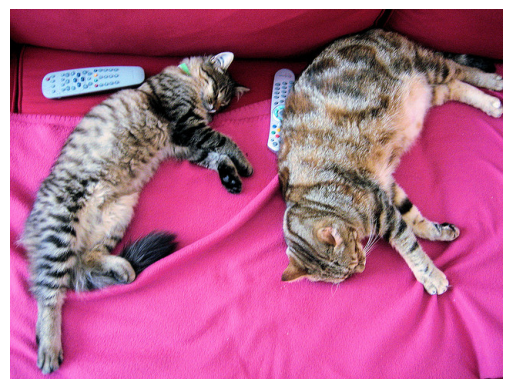

In [5]:
IMAGE_URLS = [
    "http://images.cocodataset.org/val2017/000000039769.jpg"
]


def load_image(url):
    resp = requests.get(url, timeout=10)
    return Image.open(BytesIO(resp.content)).convert("RGB")


image = load_image(IMAGE_URLS[0])
plt.imshow(image)
plt.axis("off")
plt.show()

In [6]:
conversation = [
    {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": "Describe this image in detail."}]}
]
prompt_text = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=prompt_text, images=image, return_tensors="pt").to(model.device, torch.float16)

print(prompt_text)

USER: <image>
Describe this image in detail. ASSISTANT:


In [7]:
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

image_token_id = model.config.image_token_index
image_token_positions = (inputs["input_ids"][0] == image_token_id).nonzero(as_tuple=True)[0]

print(len(outputs.hidden_states), "hidden state layers (incl. embedding)")
print(len(image_token_positions), "image token positions found")

33 hidden state layers (incl. embedding)
576 image token positions found


In [8]:
@torch.no_grad()
def llava_logit_lens(hidden_states, tokenizer, ln_f, lm_head, top_k=5, position=-1):
    results = []
    n = len(hidden_states)
    for i, layer_hidden in enumerate(hidden_states):
        h = layer_hidden[0, position, :]
        if i < n - 1:
            h = ln_f(h)
        logits = lm_head(h)
        probs = torch.softmax(logits.float(), dim=-1)
        top_probs, top_ids = probs.topk(top_k)
        results.append([
            (tokenizer.decode([tid]), float(p))
            for tid, p in zip(top_ids.tolist(), top_probs.tolist())
        ])
    return results


def print_lens(results):
    for i, layer_result in enumerate(results):
        label = "embed" if i == 0 else f"layer {i}"
        top1_tok, top1_p = layer_result[0]
        others = ", ".join(f"{t!r}:{p:.2f}" for t, p in layer_result[1:])
        print(f"{label:>9}  top1={top1_tok!r} ({top1_p:.2f})   next: {others}")


results = llava_logit_lens(outputs.hidden_states, processor.tokenizer, ln_f, lm_head, position=-1)
print_lens(results)

    embed  top1='Portail' (0.08)   next: 'ensoort':0.04, 'iemann':0.01, 'weis':0.01, '~[':0.01
  layer 1  top1='Portail' (0.23)   next: 'archivi':0.09, 'embros':0.04, 'sterd':0.02, 'пута':0.02
  layer 2  top1='sterd' (0.16)   next: 'Portail':0.03, 'idense':0.02, 'sierp':0.02, 'férences':0.02
  layer 3  top1='sterd' (0.05)   next: '<s>':0.03, 'férences':0.01, 'archivi':0.01, 'publique':0.01
  layer 4  top1='sterd' (0.14)   next: '<s>':0.04, 'publique':0.04, 'paździer':0.03, 'sierp':0.02
  layer 5  top1='sterd' (0.23)   next: 'paździer':0.07, 'sierp':0.06, 'kwiet':0.05, '<s>':0.04
  layer 6  top1='sterd' (0.20)   next: 'kwiet':0.04, 'paździer':0.04, 'sierp':0.03, '<s>':0.02
  layer 7  top1='kwiet' (0.02)   next: 'paździer':0.01, 'sierp':0.01, 'sterd':0.01, 'teil':0.01
  layer 8  top1='sierp' (0.02)   next: 'paździer':0.02, 'konn':0.01, 'kwiet':0.01, 'sterd':0.01
  layer 9  top1='幸' (0.01)   next: 'sterd':0.01, '{#':0.01, 'Soc':0.01, '索':0.00
 layer 10  top1='sterd' (0.01)   next: 'Spr':0

In [9]:
last_layer_lens_logits = lm_head(outputs.hidden_states[-1][0, -1, :])
real_logits = outputs.logits[0, -1, :]

max_diff = (last_layer_lens_logits.float().cpu() - real_logits.float().cpu()).abs().max().item()
print("max abs diff:", max_diff)
assert max_diff < 3e-2, "Error in ported logit lens -- check ln_f/lm_head wiring for LLaVA."

max abs diff: 0.015625


In [10]:
@torch.no_grad()
def image_token_confidence(hidden_states, tokenizer, ln_f, lm_head, image_token_positions, target_token, layer_idx=-1):
    """Probability of `target_token` at every image-token position, for one layer.
    Returns a (num_image_tokens,) tensor.
    """
    ids = tokenizer.encode(target_token.strip(), add_special_tokens=False)
    if len(ids) != 1:
        print(f"warning: {target_token!r} encoded to {len(ids)} tokens {ids}, using the last one")
    target_id = ids[-1]

    n = len(hidden_states)
    idx = layer_idx % n  # normalizes a negative layer_idx to a real index
    layer_hidden = hidden_states[idx]
    h = layer_hidden[0, image_token_positions, :]  # (num_image_tokens, hidden_dim)
    if idx < n - 1:
        h = ln_f(h)
    logits = lm_head(h)
    probs = torch.softmax(logits.float(), dim=-1)
    return probs[:, target_id].cpu()

In [11]:
def plot_confidence_heatmap(image, confidence, model, title=""):
    side = model.config.vision_config.image_size // model.config.vision_config.patch_size
    grid = confidence.reshape(side, side)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image)
    axes[0].set_title("image")
    axes[0].axis("off")

    im = axes[1].imshow(grid, cmap="viridis")
    axes[1].set_title(title)
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046)
    plt.tight_layout()
    safe_title = title.strip().replace(" ", "_").replace("'", "")
    plt.savefig(f"/kaggle/working/heatmap_{safe_title}.png", dpi=150, bbox_inches="tight")
    plt.show()

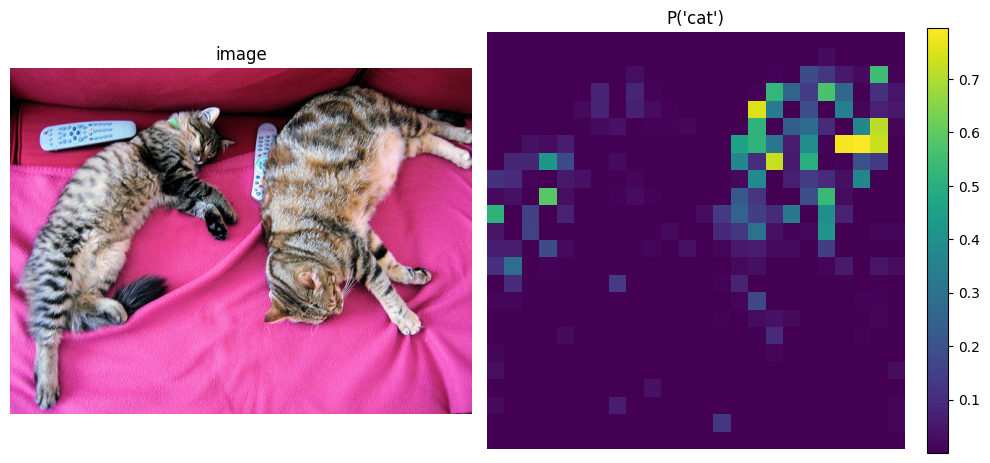

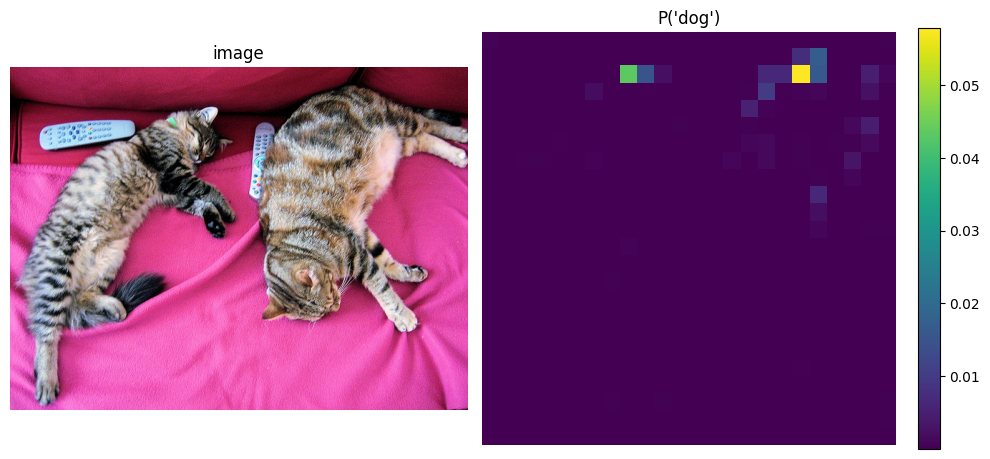

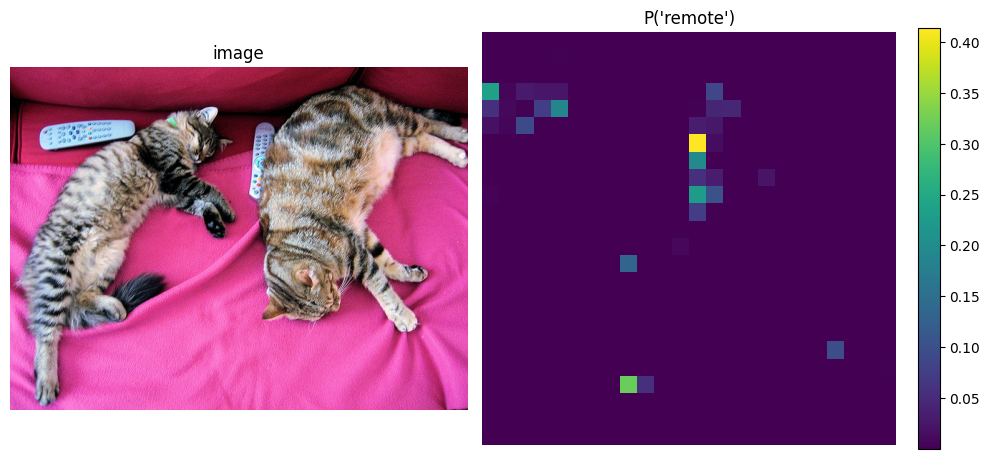

In [12]:
for word in [" cat", " dog", " remote"]:
    conf = image_token_confidence(
        outputs.hidden_states, processor.tokenizer, ln_f, lm_head, image_token_positions, word, layer_idx=-1
    )
    plot_confidence_heatmap(image, conf.numpy(), model, title=f"P({word.strip()!r})")

In [13]:
os.makedirs("/kaggle/working/cache", exist_ok=True)

image_hidden_states = torch.stack([
    layer[0, image_token_positions, :].half().cpu() for layer in outputs.hidden_states
])  # (n_layers+1, 576, hidden_dim)

torch.save(
    {
        "image_url": IMAGE_URLS[0],
        "prompt_text": prompt_text,
        "image_token_positions": image_token_positions.cpu(),
        "image_hidden_states": image_hidden_states,
    },
    "/kaggle/working/cache/day2_image0_hidden_states.pt",
)
print("saved:", image_hidden_states.shape, image_hidden_states.dtype)

saved: torch.Size([33, 576, 4096]) torch.float16
